In [1]:
# Andreev reflections in metal-semiconductor junction

import kwant
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
from typing import Tuple
from matplotlib.ticker import ScalarFormatter
from copy import deepcopy
import cmath
from types import SimpleNamespace

def pm_mod(pm, **kwargs):
    pm_lokalne = deepcopy(pm)
    for variable, value in kwargs.items():
        if value is not None:
            setattr(pm_lokalne, variable, value)
    return pm_lokalne

plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10) 

def eV2au(eV: float):
    return 0.03674932587122423*eV

def nm2au(nm: float):
    return 18.89726133921252*nm

def T2au(B: float):
    return 4.254382E-6*B

d_up = np.array([[1 , 0],
                [0 , 0]], dtype = complex)

d_dn = np.array([[0 , 0],
                [0 , 1]], dtype = complex)

s_0 = np.array([[1 , 0],
                [0 , 1]], dtype = complex)

s_x = np.array([[0 , 1],
                [1 , 0]], dtype = complex)

s_y = np.array([[0 , -1j],
                [1j , 0]], dtype = complex)

s_z = np.array([[1 , 0],
                [0 , -1]], dtype = complex)

def maker_V(pm: SimpleNamespace) -> Callable[[float], float]:

    '''
    pass SimpleNamespace parameters (pm) as:
    
    mu - chemical potential;
    x_jun - junction position in the system;
    Z - electric potential scaling constant;
    a - electric potential blur constant
    '''

    def V(x: float) -> float:

        return pm.Z*pm.mu*np.exp(-.5*(x - pm.x_jun)**2 / pm.a**2)
    
    return V

In [2]:
def plot_V(pm: SimpleNamespace, name: str = "_") -> None:

    fig, ax = plt.subplots(figsize=(4,4))
    x = np.linspace(0, pm.L, 200)
    V = maker_V(pm)
    ax.plot(x/nm2au(1.0), np.array([V(x_n)/eV2au(1.0) for x_n in x])/eV2au(1.0), color = 'k')
    ax.set_ylabel(r'$V$ (eV)')
    ax.set_xlabel(r'$x$ (nm)')
    ax.grid(True)
    fig.tight_layout()
    #ax.set_title(r"$\mu $" + f"= {pm.mu}, x_jun = {pm.x_jun}, Z = {pm.Z}, a = {pm.a}")

    plt.savefig(name + ".pdf")
    plt.show()

def disperssion(system: kwant.builder.FiniteSystem | kwant.builder.InfiniteSystem,\
                pm: SimpleNamespace, nr_lead: int,\
                k_max: float, n_k_steps: int) -> Tuple[np.ndarray, np.ndarray]:
    
    '''
    Calculate disperssion relation in a lead (nr_lead).
    '''

    bands = kwant.physics.Bands(system.leads[nr_lead])

    ks = np.linspace(-k_max*pm.dx, k_max*pm.dx, n_k_steps)
    Es = [bands(k) for k in ks]

    return (ks/pm.dx, np.asarray(Es))

def plot_disperssion(disperssion: Tuple[np.ndarray, np.ndarray],
                    y_lim: list, name: str = "_") -> None:
    
    ks, energies = disperssion

    if(y_lim[0] == y_lim[1]):
        y_lim[0] = np.min(energies)/eV2au(1.0)
        y_lim[1] = np.max(energies)/eV2au(1.0)
    
    fig, ax = plt.subplots(figsize=(4,4))
    ax.plot(ks*nm2au(1.0), energies/eV2au(1.0), color = 'k')
    ax.set_xlabel(r'$k_x$ (1/nm)')
    ax.set_ylabel(r'$E$ (eV)')
    ax.set_ylim(y_lim[0], y_lim[1])
    ax.grid(True)

    fig.tight_layout()
    plt.savefig(name + ".pdf")
    plt.show()

def TR_particle_hole(system: kwant.builder.FiniteSystem | kwant.builder.InfiniteSystem,
            energies: np.ndarray) -> SimpleNamespace:

    R_pp, R_ph, R_hp, R_hh, T_qp, T_qh = [], [], [], [], [], []
    for energy in energies:
        S = kwant.smatrix(system, energy, in_leads = (0,1), out_leads = (0,1))
        R_pp.append(S.transmission((0, 0), (0, 0)))
        R_ph.append(S.transmission((0, 0), (0, 1)))
        R_hp.append(S.transmission((0, 1), (0, 0)))
        R_hh.append(S.transmission((0, 1), (0, 1)))
        T_qp.append(S.transmission(1, (0, 0)))
        T_qh.append(S.transmission(1, (0, 1)))

    return SimpleNamespace(
            energies = energies,
            R_pp = np.asarray(R_pp),
            R_ph = np.asarray(R_ph),
            R_hp = np.asarray(R_hp),
            R_hh =  np.asarray(R_hh),
            T_qp = np.asarray(T_qp),
            T_qh = np.asarray(T_qh)
            )


In [3]:
def makesystem_fmsc(pm: SimpleNamespace) -> kwant.builder.FiniteSystem | kwant.builder.InfiniteSystem:
    
    '''
    pass SimpleNamespace parameters (pm) as:
    
    L - length of a system;
    dx - dx of the finite difference chain;
    m - mass of an electron;
    mu - chemical potential;
    x_jun - junction position in the system;
    P - exchange field constant in the ferromagnetic metal;
    Delta - superconducting pairing constant;
    Z - electric potential scaling constant;
    a - electric potential blur constant
    '''

    # (1) kinetic Hamiltonian discretization constant
    t = .5/pm.m/pm.dx**2

    # (2) exchange field h in the ferromagnetic metal map
    def h(x: float):
        return pm.P*pm.mu if x <= pm.x_jun else 0.0
    
    # (3) superconducting pairing Δ map
    def Delta(x: float):
        return pm.Delta if x > pm.x_jun else 0.0
    
    # (4) scattering region map
    def chain(pos):
        x, = pos
        return 0 <= x < pm.L
    
    # (5) electric potential around the junction
    V = maker_V(pm = pm)

    # (6) discretized Hamiltonian onsite element
    def onsite(site) -> np.ndarray:

        x, = site.pos

        onsite_00 = 2*t + V(x) - h(x) - pm.mu
        onsite_01 = Delta(x)
        onsite_10 = Delta(x)
        onsite_11 = -2*t - V(x) - h(x) + pm.mu

        return np.array([[onsite_00, onsite_01],\
                        [onsite_10, onsite_11]])
    
    # (7) discretized Hamiltonian hopping element
    def hopping(*site) -> np.ndarray:

        return np.array([[-t, 0],\
                        [0, t]])
    
    # (8) finite difference method lattice of the system
    lat = kwant.lattice.chain(pm.dx, norbs = 2)

    # (9) scattering region of the system
    sys = kwant.Builder()
    sys[lat.shape(chain, (0,))] = onsite
    sys[(lat.neighbors())] = hopping

    # (10) left (ferromagnetic) lead of the system
    llead = kwant.Builder(kwant.TranslationalSymmetry((-pm.dx,)),
                        conservation_law = np.array([[1, 0],\
                                                    [0, 2]]))
    llead[lat(0)] = onsite(SimpleNamespace(pos = (0,)))
    llead[(lat.neighbors())] = hopping
    sys.attach_lead(llead)

    # (11) right (superconducting) lead of the system
    rlead = kwant.Builder(kwant.TranslationalSymmetry((pm.dx,)))
    rlead[lat(0)] = onsite(SimpleNamespace(pos = (pm.L,)))
    rlead[(lat.neighbors())] =  hopping
    sys.attach_lead(rlead)

    # (12) finalizing the system
    return sys.finalized()


In [4]:
pm = SimpleNamespace(

    L = nm2au(500.0), # length of a system
    dx = nm2au(.2), # dx of the finite difference chain
    m = 1, # mass of an electron
    mu = eV2au(10e-3), # chemical potential
    x_jun = nm2au(250.0), # junction position in the system
    P = 0, # exchange field constant in the ferromagnetic metal
    Delta = eV2au(0.25e-3), # superconducting pairing constant
    Z = 0, # electric potential scaling constant
    a = nm2au(1.0) # electric potential blur constant

)

sys = makesystem_fmsc(pm)

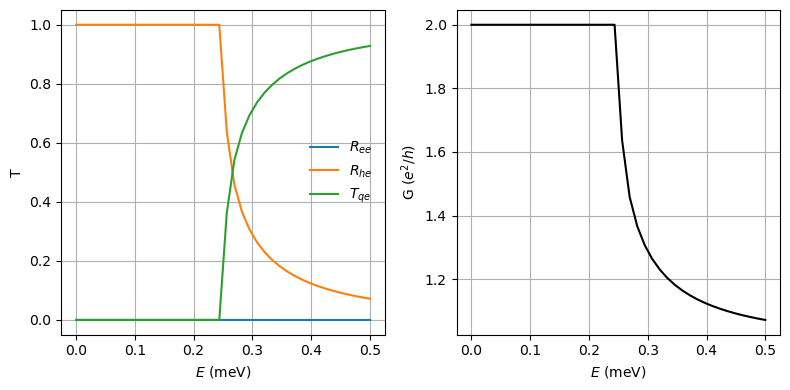

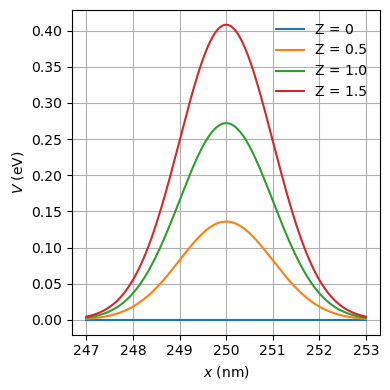

In [5]:
E = np.linspace(0, eV2au(0.5e-3), 40)

tr = TR_particle_hole(sys, energies = E)
G = 1 - tr.R_pp + tr.R_hp

fig, ax = plt.subplots(1, 2, figsize=(8,4))
ax[0].plot(1000*tr.energies/eV2au(1.0), tr.R_pp, label = r'$R_{ee}$')
ax[0].plot(1000*tr.energies/eV2au(1.0), tr.R_hp, label = r'$R_{he}$')
ax[0].plot(1000*tr.energies/eV2au(1.0), tr.T_qp, label = r'$T_{qe}$')
ax[0].set_ylabel(r'T')
ax[0].set_xlabel(r'$E$ (meV)')
ax[0].grid(True)
ax[0].legend(frameon = False)
ax[1].plot(1000*tr.energies/eV2au(1.0), G, color = 'k')
ax[1].set_ylabel(r'G ($e^2/h$)')
ax[1].set_xlabel(r'$E$ (meV)')
ax[1].grid(True)
fig.tight_layout()

plt.savefig("Rpp_Rph_Tqp_G.pdf")
plt.show()

fig_V, ax_V = plt.subplots(figsize = (4,4)); x = np.linspace(pm.x_jun - 3*pm.a, pm.x_jun + 3*pm.a, 200)
for z in [0, 0.5, 1.0, 1.5]:

    V = maker_V(pm_mod(pm, Z = z))
    ax_V.plot(x/nm2au(1.0), np.array([V(x_n)/eV2au(1.0) for x_n in x])/eV2au(1.0), label = f"Z = {z}")

ax_V.set_ylabel(r'$V$ (eV)')
ax_V.set_xlabel(r'$x$ (nm)')
ax_V.grid()
ax_V.legend(frameon = False)
fig_V.tight_layout()
plt.savefig("potential_Z.pdf")
plt.show()


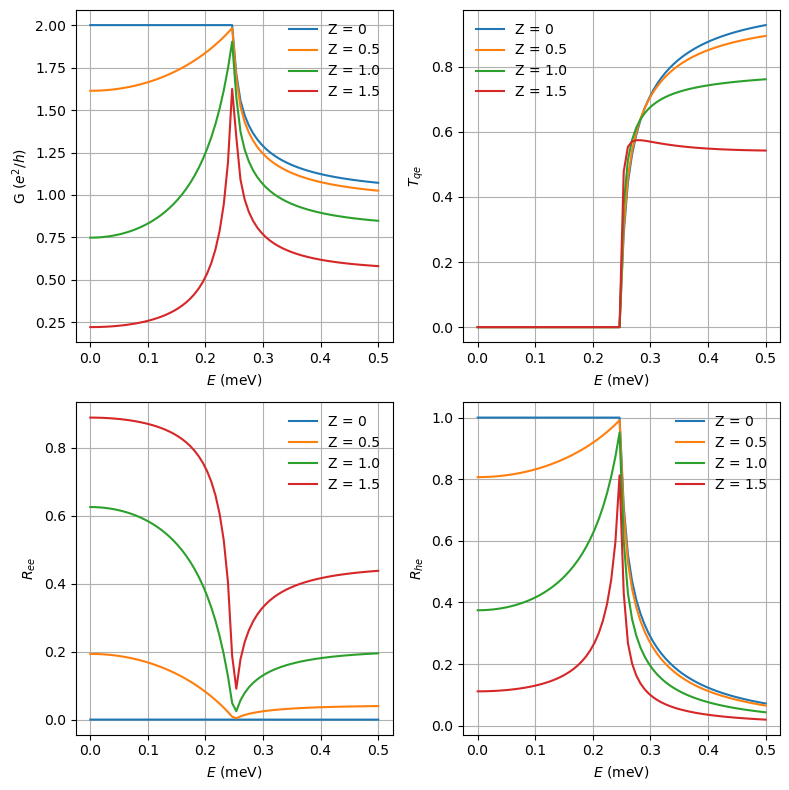

In [6]:
E = np.linspace(0, eV2au(0.5e-3), 70)
fig, ax = plt.subplots(2, 2, figsize = (8,8))
for z in [0, 0.5, 1.0, 1.5]:

    sys = makesystem_fmsc(pm_mod(pm, Z = z))
    tr = TR_particle_hole(sys, energies = E)
    G = 1 - tr.R_pp + tr.R_hp
    ax[0,0].plot(1000*tr.energies/eV2au(1.0), G, label = f'Z = {z}')
    ax[0,1].plot(1000*tr.energies/eV2au(1.0), tr.T_qp, label = f'Z = {z}')
    ax[1,0].plot(1000*tr.energies/eV2au(1.0), tr.R_pp, label = f'Z = {z}')
    ax[1,1].plot(1000*tr.energies/eV2au(1.0), tr.R_hp, label = f'Z = {z}')

ax[0,0].set_ylabel(r'G ($e^2/h$)')
ax[0,1].set_ylabel(r'$T_{qe}$')
ax[1,0].set_ylabel(r'$R_{ee}$')
ax[1,1].set_ylabel(r'$R_{he}$')

ax[0,0].set_xlabel(r'$E$ (meV)')
ax[0,1].set_xlabel(r'$E$ (meV)')
ax[1,0].set_xlabel(r'$E$ (meV)')
ax[1,1].set_xlabel(r'$E$ (meV)')

ax[0,0].legend(frameon = False)
ax[0,1].legend(frameon = False)
ax[1,0].legend(frameon = False)
ax[1,1].legend(frameon = False)

ax[0,0].grid()
ax[0,1].grid()
ax[1,0].grid()
ax[1,1].grid()

fig.tight_layout()

plt.savefig("function_of_Z.pdf")
plt.show()


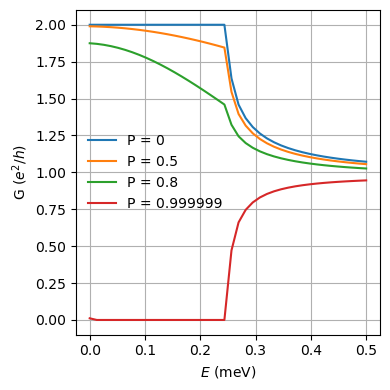

In [7]:
E = np.linspace(0, eV2au(0.5e-3), 40)
fig, ax = plt.subplots(figsize = (4,4))
for p in [0, 0.5, 0.8, 0.999999]:

    sys = makesystem_fmsc(pm_mod(pm, P = p, Z = 0))
    tr = TR_particle_hole(sys, energies = E)
    G = 1 - tr.R_pp + tr.R_hp
    ax.plot(1000*tr.energies/eV2au(1.0), G, label = f'P = {p}')

ax.set_ylabel(r'G ($e^2/h$)')
ax.set_xlabel(r'$E$ (meV)')
ax.legend(frameon = False)
ax.grid()
fig.tight_layout()

plt.savefig("G_different_P.pdf")
plt.show()

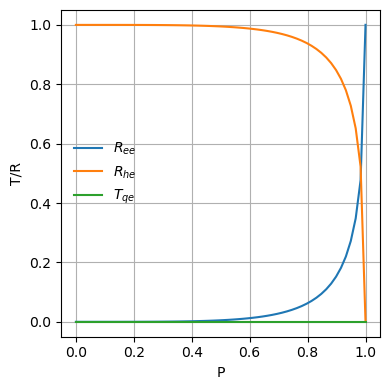

In [8]:
linsp_P = np.linspace(0, 0.99999, 60)
R_pp_P, R_hp_P, T_qp_P = [], [], []
e = eV2au(1e-6)
for p in linsp_P:

    sys = makesystem_fmsc(pm_mod(pm, P = p))
    tr = TR_particle_hole(sys, energies = np.array([e]))
    R_pp_P.append(tr.R_pp[0])
    R_hp_P.append(tr.R_hp[0])
    T_qp_P.append(tr.T_qp[0])

fig, ax = plt.subplots(figsize = (4,4))
ax.plot(linsp_P, R_pp_P, label = r"$R_{ee}$")
ax.plot(linsp_P, R_hp_P, label = r"$R_{he}$")
ax.plot(linsp_P, T_qp_P, label = r"$T_{qe}$")

ax.set_ylabel(r'T/R')
ax.set_xlabel(r'P')
ax.legend(frameon = False)
ax.grid()
fig.tight_layout()

plt.savefig("TR_P.pdf")
plt.show()


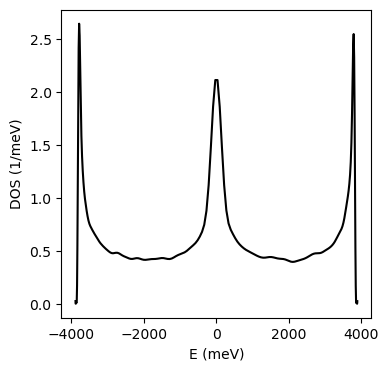

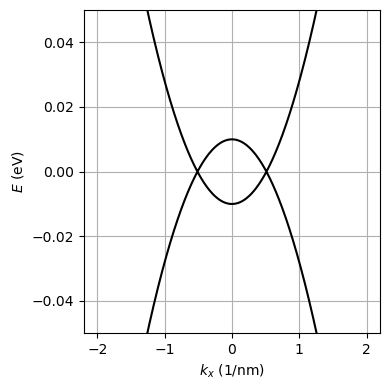

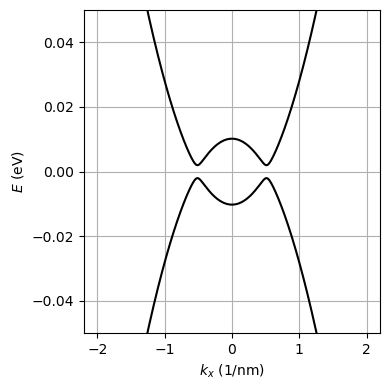

In [9]:
pm = SimpleNamespace(

    L = nm2au(500.0), # length of a system
    dx = nm2au(.2), # dx of the finite difference chain
    m = 1, # mass of an electron
    mu = eV2au(10e-3), # chemical potential
    x_jun = nm2au(250.0), # junction position in the system
    P = 0, # exchange field constant in the ferromagnetic metal
    Delta = eV2au(2e-3), # superconducting pairing constant
    Z = 0, # electric potential scaling constant
    a = nm2au(1.0) # electric potential blur constant

)

sys = makesystem_fmsc(pm)
en, dens = kwant.kpm.SpectralDensity(sys)()
fig, ax = plt.subplots(figsize = (4,4))
ax.plot(1000*en/eV2au(1.0), np.real(dens)*eV2au(1.0e-3), color = 'k')
ax.set_xlabel("E (meV)")
ax.set_ylabel("DOS (1/meV)")
plt.show()

disp = disperssion(system = sys, pm = pm, nr_lead = 0,
                k_max = 2/nm2au(1.0), n_k_steps = 1000)
plot_disperssion(disp, y_lim = [-0.05, 0.05])

disp_2 = disperssion(system = sys, pm = pm, nr_lead = 1,
                k_max = 2/nm2au(1.0), n_k_steps = 1000)
plot_disperssion(disp_2, y_lim = [-0.05, 0.05])